# First RL Implementation


## 1 Task

Agent needs to manage portfolio of asset (e.g. stock) and cash by changing allocations. 
Goal is to maximize portfolio value at end of episode t=100.
Initial allocation is 50/50 of 100 USD budget.


## 2 Markov Decision Process

- State: price change (up or down)
- Action: changing allocation by +- 10% or stay (3 actions)
- Reward: return of asset multiplied by allocation

## 3 RL Model

- tabular Q-learning with 2 states and 3 actions, so 6 Q-values

## 4 Market Simulation

- start with normal distribution

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from generators import NormalPriceGenerator, LinearPriceGenerator
from agents import HoldAgent, QLearningAgent
from environments import PortfolioEnvironment

In [43]:
# initialize agent, generator and environment
agent = QLearningAgent(alpha=0.1, gamma=0.9, epsilon=0.1, num_actions=3, num_states=2)
generator = LinearPriceGenerator()
env = PortfolioEnvironment(generator, agent)

# run the environment
n = 100
a0_list = []
a1_list = []
a2_list = []
n_episodes = 100

env.agent.q = np.array([[0, 0, 0], [0, 100, 0]])

for j in range(n_episodes):

    env.reset()
    for i in range(n):
        state, reward = env.step()

    a0_list.append(env.agent.q[1, 0])
    a1_list.append(env.agent.q[1, 1])
    a2_list.append(env.agent.q[1, 2])
    




In [44]:
env.agent.q

array([[  0,   0,   0],
       [494, 535, 578]])

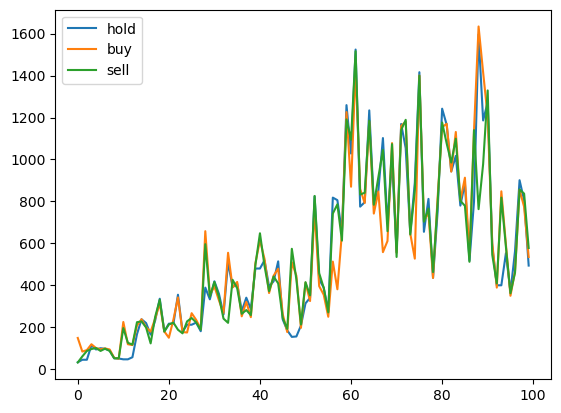

In [45]:
# plot the results
plt.plot(a0_list, label='hold')
plt.plot(a1_list, label='buy')
plt.plot(a2_list, label='sell')
plt.legend()
plt.show()

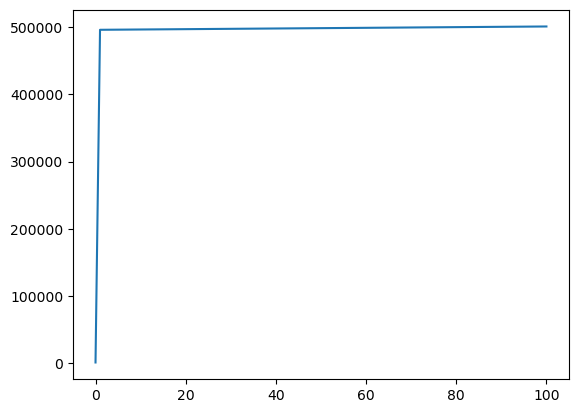

In [25]:
plt.plot(env.pvs)

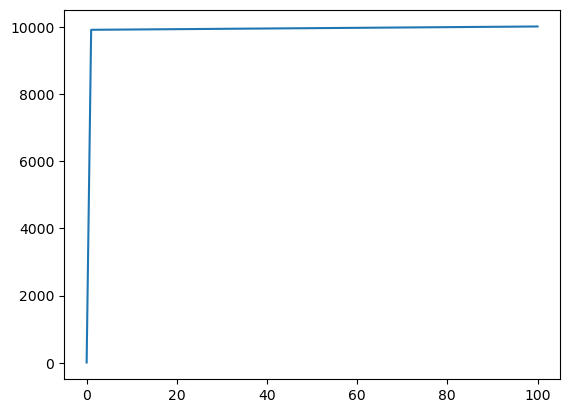

In [26]:
plt.plot(env.prices)

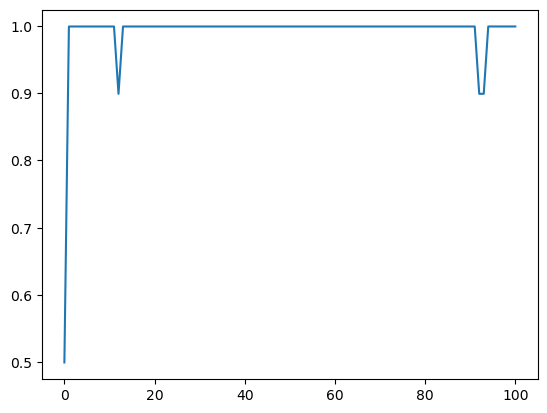

In [27]:
plt.plot(env.allocations)

In [28]:
max(env.allocations)

0.9990289100006943

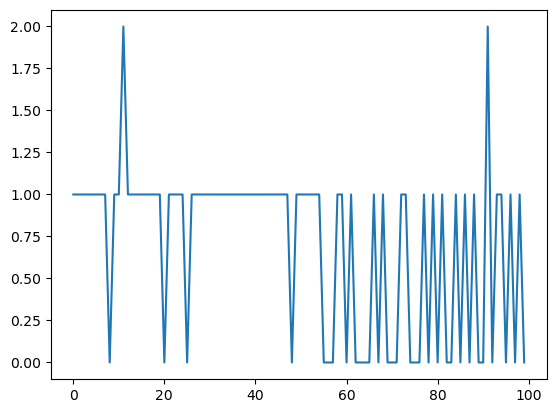

In [29]:
plt.plot(env.actions)

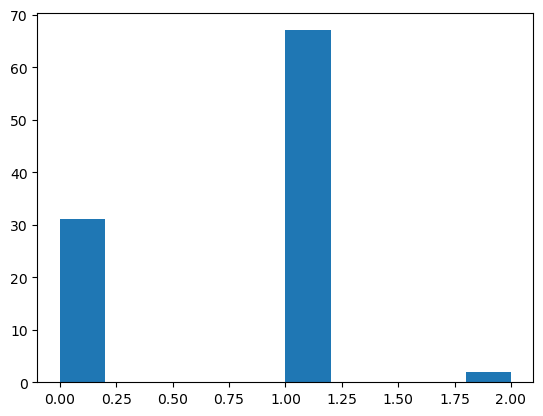

In [30]:
plt.hist(env.actions);

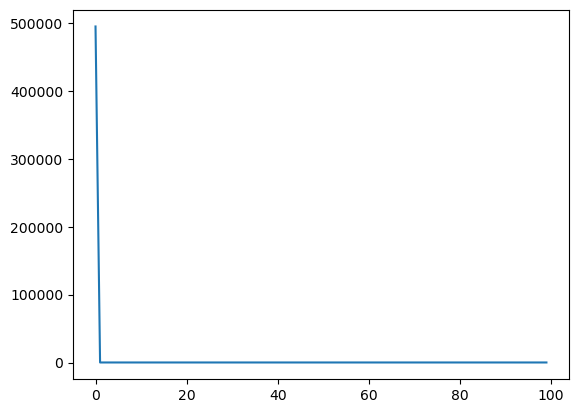

In [31]:
plt.plot(env.rewards)

4999.849800242025

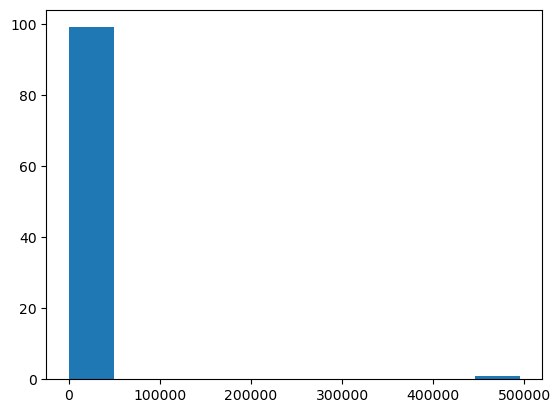

In [32]:
plt.hist(env.rewards);
np.mean(env.rewards)

In [33]:
np.std(env.rewards)

49251.89323981921